In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Task 1: Classify the Problem Type
# a) Predict whether a tumor is malignant or benign. -> Classification
# b) Predict the exact blood pressure reading of a patient. -> Regression
# c) Predict delivery ETA in minutes for a Zomato order. -> Regression
# d) Predict whether an email is spam or not spam. -> Classification

In [2]:
# Task 2: Manual Calculation: A model is built to predict salary (LPA) from years of experience.
# b0 = 3.5, b1 = 1.2
# a) Write the full model equation.
#    Salary = 3.5 + 1.2 * YearsOfExperience
# b) Predict salary for 5 years of experience.
pred_salary = 3.5 + 1.2 * 5
print(f"Predicted salary for 5 years: {pred_salary} LPA")
# c) If actual salary is 10 LPA for 5 years experience, what is the residual?
actual_salary = 10
residual = actual_salary - pred_salary
print(f"Residual: +{residual} LPA")

Predicted salary for 5 years: 9.5 LPA
Residual: +0.5 LPA


In [3]:
# Task 3: Conceptual Question: A model has MSE = 144 on the test set.
# a) What is the RMSE? What does it tell you?
rmse = np.sqrt(144)
print(f"RMSE is {rmse}. It tells us the average magnitude of the prediction error.")
# b) If the target variable Y is house price in Lakhs, what does RMSE = 12 Lakhs mean in plain English?
print("It means that on average, our model's predictions are off by 12 Lakhs from the actual house prices.")
# c) Would you prefer MAE=10 or RMSE=10 as a metric if your dataset has many outliers? Why?
print("MAE is preferred because it is less sensitive to outlier errors (it doesn't square the large errors).")

RMSE is 12.0. It tells us the average magnitude of the prediction error.
It means that on average, our model's predictions are off by 12 Lakhs from the actual house prices.
MAE is preferred because it is less sensitive to outlier errors (it doesn't square the large errors).


In [4]:
# Task 4: MLR Interpretation: Student exam score = 20 + 4.5*StudyHours + 2.1*Sleep + 0.3*Attendance
# a) Predict score for: 6 study hours, 7 sleep hours, 85% attendance.
score = 20 + (4.5 * 6) + (2.1 * 7) + (0.3 * 85)
print(f"Predicted score: {score}")
# b) Which feature has the most influence per unit change?
print("StudyHours has the most influence because its coefficient (4.5) is the largest.")
# c) If R^2 = 0.72, how much variance in score does the model NOT explain?
print(f"{100 - (0.72 * 100)}% of the variance is unexplained.")

Predicted score: 87.2
StudyHours has the most influence because its coefficient (4.5) is the largest.
28.0% of the variance is unexplained.


In [5]:
# Task 5: Metric Selection
# a) Predicting patient blood glucose (40-pt error dangerous). 
print("a) Use RMSE because it heavily penalises large errors.")
# b) Predicting monthly electricity consumption (outliers skew data). 
print("b) Use MAE because it is robust to outliers.")
# c) Comparing two models with different number of features. 
print("c) Use Adjusted R^2, as plain R^2 will always increase when adding features even if they are useless.")

a) Use RMSE because it heavily penalises large errors.
b) Use MAE because it is robust to outliers.
c) Use Adjusted R^2, as plain R^2 will always increase when adding features even if they are useless.


In [6]:
# Task 6: Hands-On Coding Task using the provided MLR data
data = {
 'size': [600,750,900,1100,1300,1500,1800,2000,2200,2500,700,1000,1600,2100,950],
 'bedrooms': [ 1, 2, 2, 3, 3, 3, 4, 4, 5, 5, 2, 3, 4, 5, 2],
 'location': [ 5, 6, 7, 7, 8, 8, 9, 9, 10, 10, 4, 6, 8, 9, 5],
 'age': [ 10, 5, 15, 8, 3, 2, 1, 0, 0, 0, 20, 12, 6, 0, 18],
 'price': [ 25, 35, 40, 52, 63, 72, 88, 98, 112, 125, 28, 46, 78, 105, 37],
}
df = pd.DataFrame(data)

# a) Select 3 features: let's pick size, location, age
X = df[['size', 'location', 'age']]
y = df['price']

# b) Split 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# c) Train model and print coeffs
model = LinearRegression()
model.fit(X_train, y_train)
print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_)))

# d) Evaluate
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

# e) Which feature had highest absolute coefficient?
abs_coefs = np.abs(model.coef_)
max_feat = X.columns[np.argmax(abs_coefs)]
print(f"Highest absolute coefficient is for '{max_feat}'.")
# This tells us that a 1-unit change in location has the largest absolute impact on price, but units are different!

# f) StandardScaler before training
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model_sc = LinearRegression().fit(X_train_sc, y_train)
y_pred_sc = model_sc.predict(X_test_sc)
print("R2 with scaling:", r2_score(y_test, y_pred_sc))
print("R2 doesn't change for linear regression predictions, but scaling makes coefficients comparable.")

Intercept: -7.160246263279689
Coefficients: {'size': np.float64(0.04878276157053576), 'location': np.float64(0.9851159803941402), 'age': np.float64(-0.24571991818167505)}
MAE: 0.72993965412079
RMSE: 0.8766847736410943
R2: 0.9995853503338324
Highest absolute coefficient is for 'location'.
R2 with scaling: 0.9995853503338327
R2 doesn't change for linear regression predictions, but scaling makes coefficients comparable.


New R2: 0.9979073791608343
Garage coefficient: -0.3327252800436795
In business terms, having a garage adds approximately -0.33 Lakhs to the predicted house price.


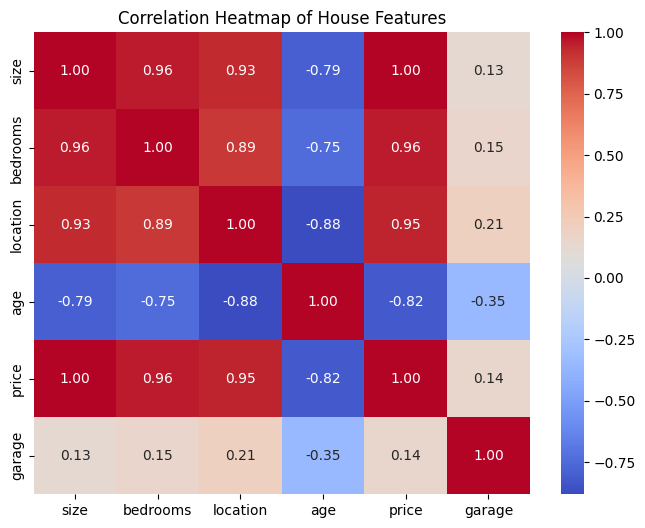

In [7]:
# Task 7: Exploratory Challenge: Modify the MLR model above
# a) Add a new feature 'garage'
df['garage'] = [0,1,0,1,1,1,0,1,0,1,0,1,1,0,0]

X_new = df[['size', 'bedrooms', 'location', 'age', 'garage']]
y_new = df['price']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

# b) Retrain the model. Does R2 improve?
model2 = LinearRegression().fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)
print("New R2:", r2_score(y_test2, y_pred2))

# c) Coefficient for 'garage'
garage_idx = list(X_new.columns).index('garage')
garage_coef = model2.coef_[garage_idx]
print("Garage coefficient:", garage_coef)
print(f"In business terms, having a garage adds approximately {garage_coef:.2f} Lakhs to the predicted house price.")

# d) Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of House Features")
plt.show()